# General Constrained Sampling

Michael Fatemi, 3/9/2026

This notebook includes several small-scale tests regarding the ability to sample from constrained distributions. We assess the coverage of the constrained distribution, and the affect of the annealing duration on this coverage. The general principle is that one can treat constraint satisfaction problems as attempting to perform Langevin dynamics sampling over a uniform distribution on a feasible set.

## Definition

Let's say we're trying to optimize over values in $\R^n$. Then the most general formulation of a constrained optimization problem is:
\begin{align*}
\min\ 						  & f(x) \\
\text{subject to}\  & g_i(x) = 0 \\
										& h_j(x) \leq 0
\end{align*}
Where $g_i: \R^n \to \R$ are functions having a feasible region denoted by $\mathcal{C}_i := g_i^{-1}(0)$, and $h_j: \R^n \to \R$ are functions having a feasible region denoted by $\mathcal{C}_j := h_i^{-1}((-\infty, 0])$. For simplicity, we will denote all feasible regions by $\mathcal{C}_i$, where the value of $i$ determines whether the feasible region corresponds to an equality or an inequality constraint. Therefore, if a value $x \in \R^n$ satisfies $x \in \mathcal{C}_i$, then $x$ satisfies constraint $i$. The overall feasible region for the problem is the feasible region for which all constraints are satisfied: $\mathcal{C} := \bigcap_i \mathcal{C}_i$. This is because $x \in \mathcal{C} \iff x \in \mathcal{C}_i \, \forall \, i$, representing the satisfaction of all constraints.

## Examples

- For a linear equality constraint $Ax = 0$, where $x \in V$ (a vector space) and $A \in V^*$ (the dual space), the feasible region is $\mathcal{C} \sube V$ a hyperplane.
- For a discrete constraint, i.e. $x \in \{0, 1, 2\}$, the feasible region is $\mathcal{C} = \{0, 1, 2\}$.
- For the inequality constraint $x \leq 0$ (for $x \in \R$), the feasible region is $\mathcal{C} = (-\infty, 0]$.
- For the inequality constraint $x + y \leq 0$ (for $x, y \in \R$), the feasible region is $\mathcal{C} = \{(x, y) \in \R^2 : x \leq -y \}$.
- For an "and" constraint on $x, y \in \{0, 1\}$, $x = 1, y = 1$, the feasible region is $\mathcal{C} = \{(1, 1)\}$.
- For an "or" constraint on $x, y \in \{0, 1\}$, $x = 1$ or $y = 1$, the feasible region is $\mathcal{C} = \{(0, 1), (1, 0), (1, 1)\}$.

## Convolved Distributions

Now, let's say we want to sample from a feasible region. To do this, we can consider annealed Langevin dynamics sampling. We must first define a distribution over the feasible region. For now, consider a bounded feasible region with nonzero measure. That is, $\mathcal{C} \sube B_r(0)$ for some $r \in \R$ finite, with $m(\mathcal{C}) > 0$ (where $m$ is the Lebesgue outer measure). Then we can define a probability space $(\Omega, \mathcal{F}, P)$, where $\Omega = \R^n$, $\mathcal{F} = \mathcal{B}$ (the Borel $\sigma$-algebra generated on $\R^n$), and $P(F) = \frac{m(F \cap \mathcal{C})}{m(\mathcal{C})}$. This is a uniform distribution over $\mathcal{C}$. Then let $P_\sigma$ be the same distribution, convolved with a normal distribution of variance $\sigma^2$, having probability density $p_\sigma$ given by:
$$
p_\sigma(x) = \int_{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}
$$
The "score" of this distribution is the gradient of log-probability:
\begin{align*}
\nabla_x \log p_\sigma(x)
&= \frac{\int_{\R^n} \nabla_x \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}}{\int_{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}} \\
&= \frac{\int_{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \nabla_x \log \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}}{\int_{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}} \\
&= \frac{\int_{\R^n} \frac{\tilde{x} - x}{\sigma^2} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}}{\int_{\R^n} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) p(\tilde{x}) \, d\tilde{x}} \\
&=: \frac{N(x)}{D(x)}
\end{align*}
Where $N(x)$ refers to the "numerator" and $D(x)$ refers to the "denominator". This can then be used for sampling.

### Lower-Dimensional Convolved Distributions

The case above only applies for $m(\mathcal{C}) > 0$. However, for equality constraints, the feasible region is of lower dimension than the original space. To address this, we can let $g: \R^n \to \R$ represent the equality constraint $\mathcal{C} = g^{-1}(0)$. We may further require that the feasible region be a manifold; i.e., for the codimension $1$ case, $\nabla_x g(x) \neq 0$ for all $x \in \mathcal{C}$. Then we may define the feasible region $\mathcal{C}_{\epsilon} := g^{-1}(B_\epsilon(0))$. This has nonzero Lebesgue outer measure. Then we may take the limit of the full-dimensional case as $\epsilon \to 0$. For example, in the case of a plane, the score function will point normal to the plane. In the case of a feasible region defined by a set of points, the score function will be the same as that of a mixture of Gaussians with the mean of each Gaussian centered at each of the points.

## Example with Visualizations

Let's try sampling from the interval $[0, 1] \in \R$. We will try computing the score at a point $x \in \R$. Computing the score here can be done with the generalized Stokes theorem:
\begin{align*}
\nabla_x \log p_\sigma(x)
= \frac{\int_{\mathcal{C}} \nabla_x \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I) \, d\tilde{x}}{\int_{\mathcal{C}} \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I) \, d\tilde{x}}
= \frac{\int_{\delta \mathcal{C}} \mathcal{N}(\tilde{x} - x; 0, \sigma^2 I)}{\int_{\delta \mathcal{C}} \Phi(\frac{\tilde{x} - x}{\sigma})}
= \frac{\mathcal{N}(1 - x; 0, \sigma^2 I) - \mathcal{N}(-x; 0, \sigma^2 I)}{\Phi(\frac{1 - x}{\sigma}) - \Phi(\frac{-x}{\sigma})}
\end{align*}
Where $\Phi(x) = \int_{-\infty}^{x} \mathcal{N}(x; 0, I) \, dx$ is the Gaussian cumulative distribution function. We can visualize this at different noise levels $\sigma$. Note that the denominator, in this case, is $p_\sigma(x)$ itself.

<!-- We want:
$$
N(x) = \int_0^1 \frac{\tilde{x} - x}{\sigma^2} \mathcal{N}(x - \tilde{x}; 0, \sigma^2 I) \, d\tilde{x}
$$
If we change coordinates to $\epsilon = \frac{\tilde{x} - x}{\sigma}$, we have:
$$
N(x)
= \int_{\frac{x}{\sigma}}^{\frac{x - 1}{\sigma}} \epsilon \mathcal{N}(\epsilon; 0, I) \, d\epsilon
= \int_{\frac{x}{\sigma}}^{\frac{x - 1}{\sigma}} \frac{\epsilon}{\sqrt{2 \pi}} \exp\left(-\frac{\epsilon^2}{2}\right) \, d\epsilon
$$
Then note,
\begin{align*}
N(x)
&= \frac{1}{\sqrt{2 \pi}} \int_{\frac{x}{\sigma}}^{\frac{x - 1}{\sigma}} \frac{\partial}{\partial \epsilon} \exp\left(-\frac{\epsilon^2}{2}\right) \, d\epsilon \\
&= \left. \mathcal{N}(\epsilon; 0, I) \right|_{\epsilon = \frac{x - 1}{\sigma}}^{\frac{x}{\sigma}} \\
&= \mathcal{N}(x - 1; 0, \sigma^2 I) - \mathcal{N}(x; 0, \sigma^2 I)
\end{align*} -->

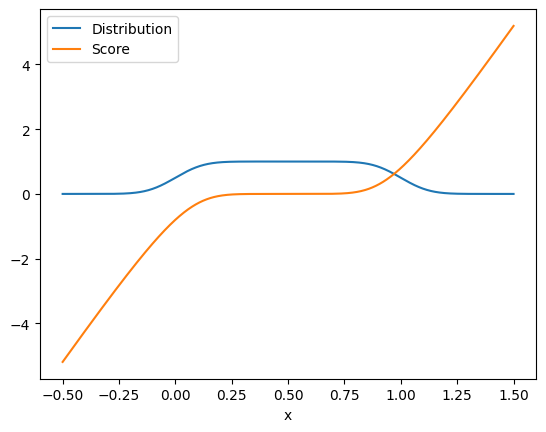

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

sigma = 0.1
x = np.linspace(-0.5, 1.5, 1000)

N = norm.pdf((1 - x) / sigma) - norm.pdf((-x / sigma))
D = norm.cdf((1 - x) / sigma) - norm.cdf((-x / sigma))

plt.plot(x, D, label='Distribution')
plt.plot(x, N / D, label='Score')
plt.xlabel('x')
plt.legend()
plt.show()


We see that the score gets increasingly powerful the further away one gets from the feasible region. However, I have purposefully truncated the bounds of the graph. Due to numerical precision errors, we start to get nonsense at far distances from the feasible region.

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2454122752.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x, N / D, label='Score')


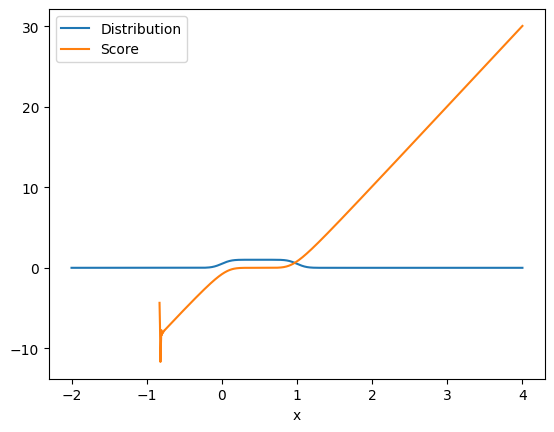

In [13]:
sigma = 0.1
x = np.linspace(-2, 4, 1000)

N = norm.pdf((1 - x) / sigma) - norm.pdf((-x / sigma))
D = norm.cdf((1 - x) / sigma) - norm.cdf((-x / sigma))

plt.plot(x, D, label='Distribution')
plt.plot(x, N / D, label='Score')
plt.xlabel('x')
plt.legend()
plt.show()


To address this, we can note that Scipy provides a $\log \Phi$. Then we can cancel out any constant factors between the numerator and denominator, while preserving numerical stability. Sometimes the result for $\log \Phi$ is *extremely* small, in which case we cannot even compute $\log D = \log(\exp(\log \Phi(\frac{1 - x}{\sigma})) - \exp(\log \Phi(\frac{-x}{\sigma})))$ numerically. In these cases, we can recognize that for very small $\log \Phi(\frac{1 - x}{\sigma})$, $\exp(\log \Phi(\frac{1 - x}{\sigma})) \approx 1 + \log \Phi(\frac{1 - x}{\sigma})$. The $1$ values will cancel out, leaving only the first-order terms remaining. Then $\log(\exp(\log \Phi(\frac{1 - x}{\sigma})) - \exp(\log \Phi(\frac{-x}{\sigma}))) \approx \log (\log \Phi(\frac{1 - x}{\sigma}) - \log \Phi (\frac{-x}{\sigma}))$. This value is stored in the `log_D_method_2` variable below. We see that more broadly, the score function pulls us to the feasible region strongly when we are outside of it. But, inside the feasible region, there is little "preference" as to where we are inside the feasible region, reflecting the fact that our original distribution was uniform over the feasible region.

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2159770297.py:10: RuntimeWarning: divide by zero encountered in log
  log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D


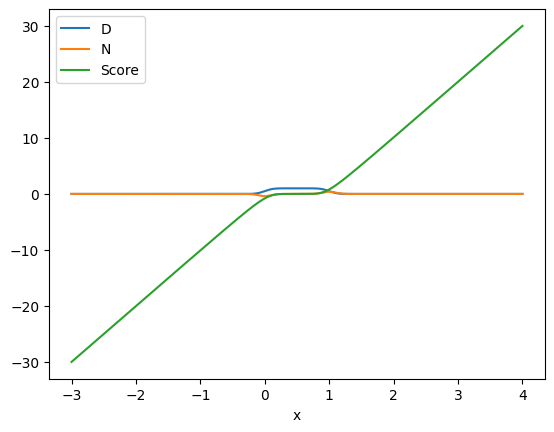

In [ ]:
from scipy.special import log_ndtr

sigma = 0.1
x = np.linspace(-3, 4, 1000)

log_D1 = log_ndtr((1 - x) / sigma)
log_D2 = log_ndtr(-x / sigma)

base_D = np.maximum(log_D1, log_D2)
log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
log_D_method_2 = np.log(log_D1 - log_D2)
log_D = np.where(np.abs(base_D) > 1e-50, log_D_method_1, log_D_method_2)
D = np.exp(log_D)

log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
base_N = np.maximum(log_N1, log_N2)
log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
N = np.exp(log_N) * np.sign(log_N1 - log_N2)


N_over_D = np.exp(log_N - log_D) * np.sign(log_N1 - log_N2)

plt.plot(x, D, label='D')
plt.plot(x, N, label='N')
plt.plot(x, N_over_D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


But, it seems that for very small $\sigma$ values, this too fails.

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/528109327.py:10: RuntimeWarning: divide by zero encountered in log
  log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/528109327.py:11: RuntimeWarning: divide by zero encountered in log
  log_D_method_2 = np.log(log_D1 - log_D2)


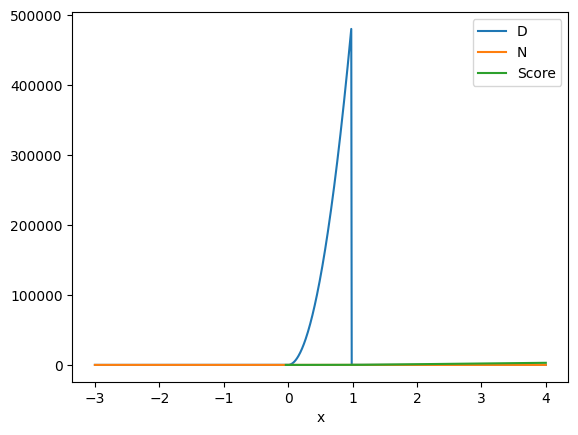

In [74]:
from scipy.special import log_ndtr

sigma = 0.001
x = np.linspace(-3, 4, 1000)

log_D1 = log_ndtr((1 - x) / sigma)
log_D2 = log_ndtr(-x / sigma)

base_D = np.maximum(log_D1, log_D2)
log_D_method_1 = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
log_D_method_2 = np.log(log_D1 - log_D2)
log_D = np.where(np.abs(base_D) > 1e-50, log_D_method_1, log_D_method_2)
D = np.exp(log_D)

log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
base_N = np.maximum(log_N1, log_N2)
log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
N = np.exp(log_N) * np.sign(log_N1 - log_N2)


N_over_D = np.exp(log_N - log_D) * np.sign(log_N1 - log_N2)

plt.plot(x, D, label='D')
plt.plot(x, N, label='N')
plt.plot(x, N_over_D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


A more robust to compute this is that for very large denominator inputs, we can negate the input to $\log \Phi$. This results in $\log 1 - \Phi$. Since $1 - \Phi$ will be close to zero, the $\log$ will have more meaning. In fact, one can numerically evaluate $\log 1 - \operatorname{erf}$ for very large $x$. Using this approach, we observe stability even for (very) small $\sigma$. In this limit, the score function points us directly to the feasible region. This resembles a *projection*. Furthermore, note that as $\sigma$ decreases, the *strength* of the pull back to the feasible region gets significantly stronger.

/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1097444700.py:9: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/1097444700.py:15: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


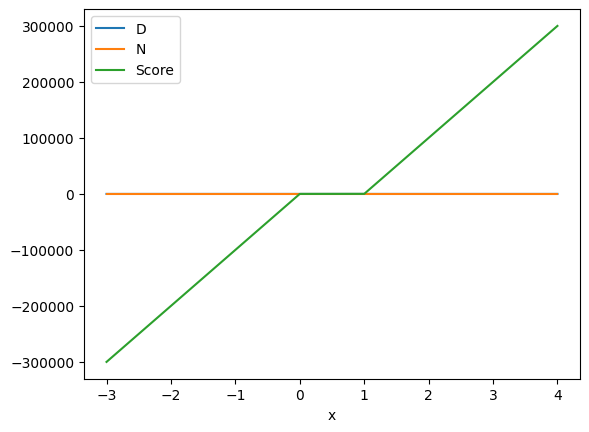

In [81]:
from scipy.special import log_ndtr

sigma = 0.00001
x = np.linspace(-3, 4, 1000)

log_D1 = log_ndtr((1 - x) / sigma)
log_D2 = log_ndtr(-x / sigma)
base_D = np.maximum(log_D1, log_D2)
log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D

log_D1_alt = log_ndtr((x - 1) / sigma)
log_D2_alt = log_ndtr(x / sigma)
base_D_alt = np.maximum(log_D1_alt, log_D2_alt)
log_D_alt = (
    np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
    + base_D_alt
)
log_D = np.where(x > 0, log_D, log_D_alt)
D = np.exp(log_D)

log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
base_N = np.maximum(log_N1, log_N2)
log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
N = np.exp(log_N) * np.sign(log_N1 - log_N2)


N_over_D = np.exp(log_N - log_D) * np.sign(log_N1 - log_N2)

plt.plot(x, D, label="D")
plt.plot(x, N, label="N")
plt.plot(x, N_over_D, label="Score")
plt.xlabel("x")
plt.legend()
plt.show()


We can now visualize what happens if we anneal $\log \sigma$ linearly.

In [106]:
from scipy.special import log_ndtr
from io import BytesIO
import PIL.Image
import av
from IPython.display import Video

nframes = 30
images = []
bytes_io = BytesIO()
for log_sigma in np.linspace(np.log(10), np.log(0.00001), nframes):
    sigma = np.exp(log_sigma)
    x = np.linspace(0 - 10 * sigma - 0.1, 1 + 10 * sigma + 0.1, 1000)

    log_D1 = log_ndtr((1 - x) / sigma)
    log_D2 = log_ndtr(-x / sigma)
    base_D = np.maximum(log_D1, log_D2)
    log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D

    log_D1_alt = log_ndtr((x - 1) / sigma)
    log_D2_alt = log_ndtr(x / sigma)
    base_D_alt = np.maximum(log_D1_alt, log_D2_alt)
    log_D_alt = (
        np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))
        + base_D_alt
    )
    log_D = np.where(x > 0, log_D, log_D_alt)
    D = np.exp(log_D)

    log_N1 = -0.5 * (((1 - x) / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
    log_N2 = -0.5 * ((-x / sigma) ** 2) - 0.5 * np.log(2 * np.pi)
    base_N = np.maximum(log_N1, log_N2)
    log_N = np.log(np.abs(np.exp(log_N1 - base_N) - np.exp(log_N2 - base_N))) + base_N
    N = np.exp(log_N) * np.sign(log_N1 - log_N2)

    N_over_D = np.exp(log_N - log_D) * np.sign(log_N1 - log_N2)

    plt.plot(x, D, label="D")
    plt.plot(x, N, label="N")
    plt.plot(x, N_over_D, label="Score")
    plt.xlabel("x")
    plt.legend()
    plt.savefig(bytes_io, format="png")
    plt.clf()
    img = PIL.Image.open(bytes_io).convert("RGB")
    images.append(img)

    bytes_io.truncate(0)
    bytes_io.seek(0)

with av.open("animation.mp4", mode="w") as container:
    stream = container.add_stream("h264", rate=10)
    stream.width = images[0].width
    stream.height = images[0].height
    stream.pix_fmt = "yuv420p"

    for img in images:
        packet = stream.encode(av.VideoFrame.from_image(img))
        container.mux(packet)

    # Flush the encoder
    for packet in stream.encode(None):
        container.mux(packet)

Video("animation.mp4")


/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2069881474.py:17: RuntimeWarning: divide by zero encountered in log
  log_D = np.log(np.exp(log_D1 - base_D) - np.exp(log_D2 - base_D)) + base_D
/var/folders/pt/45xmzdh176jcsmxv9vb4by_c0000gn/T/ipykernel_46495/2069881474.py:23: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(log_D2_alt - base_D_alt) - np.exp(log_D1_alt - base_D_alt))


<Figure size 640x480 with 0 Axes>